### Organize data for segmentation and ensure GPU is available

In [1]:
# Configure parameters and path names for segmentation

experiment = 'SFv7_December_2024'
segname = 'dapi'
data_folder = r'D:\241207_WTC11_SFv7'
save_dir = f'D:\\241207_WTC11_SFv7\\{experiment}\\{segname}'

from ioMicro import read_im
import numpy as np
import glob
import zarr
import os

In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import torch
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA RTX A6000'

In [4]:
!nvidia-smi

Wed Dec 25 12:41:47 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 552.12                 Driver Version: 552.12         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:21:00.0  On |                  N/A |
|  0%   43C    P8             11W /  170W |    1844MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Identify and count files (fovs) to segment 

zarr_files = r'D:\241207_WTC11_SFv7\H8_MER\Conv_zscan1_*.zarr'
files = list(sorted(list(glob.glob(zarr_files))))
print(f"Found {len(files)} files to segment")

Found 184 files to segment


In [6]:
# Read image data from each fov using read_im function from ioMicro

im_path = r'D:\241207_WTC11_SFv7\H8_MER\*'
imgs = [read_im(im_path) for im_path in files]
# imgs_DAPI = [read_im(im_path) for im_path in files]

In [7]:
imgs[15][3,:,:,:].shape

(40, 2800, 2800)

In [8]:
imgs[20]

dask.array<swapaxes, shape=(4, 40, 2800, 2800), dtype=uint16, chunksize=(4, 1, 2800, 2800), chunktype=numpy.ndarray>

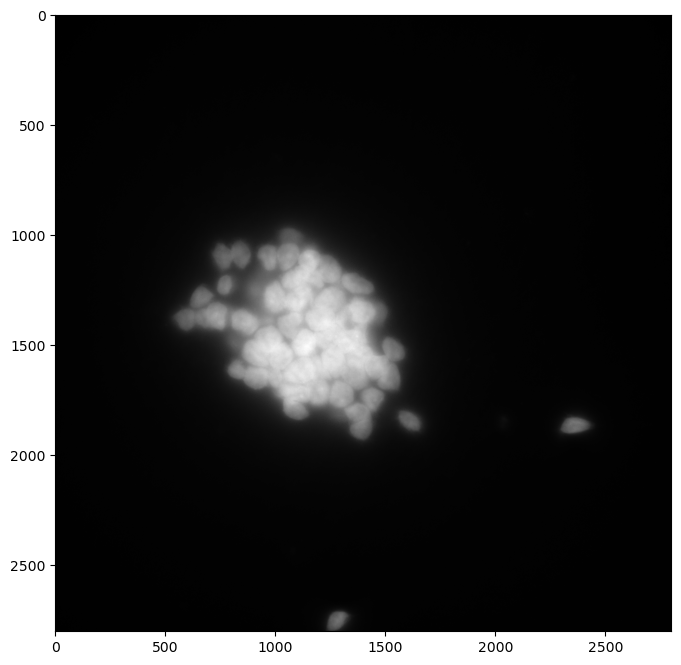

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(imgs[22][3,15,:,:], cmap='gray', vmax=15000)

#### Specify single polyA/dapi slice from each fov to use for segmentation 

In [13]:
for i in range(184):
    imgs[i] = imgs[i][3,15,:,:]

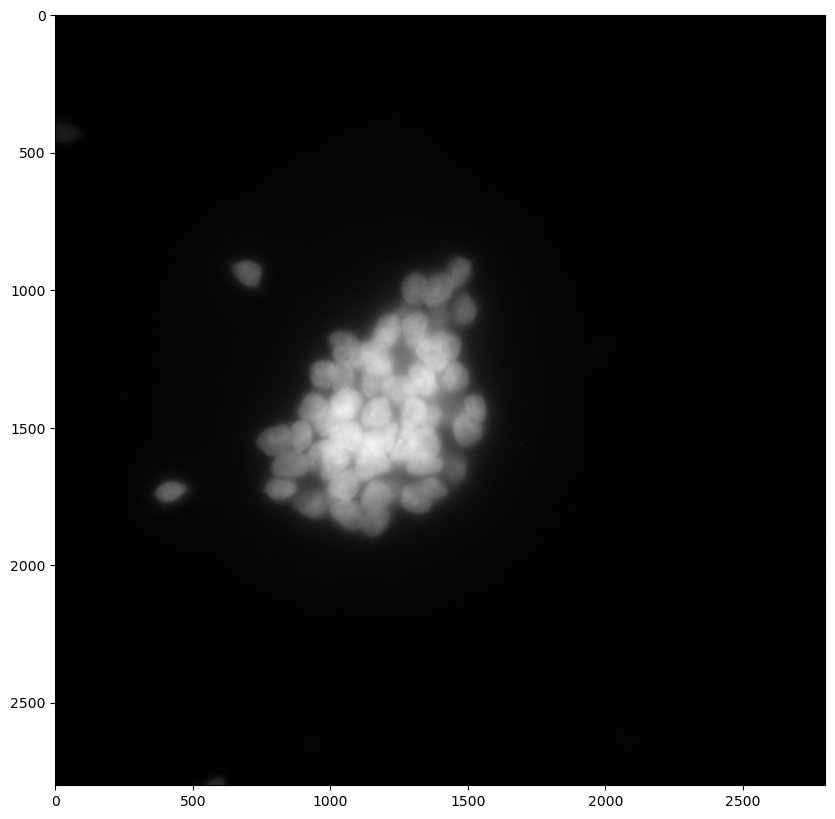

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,10))

ax.imshow(imgs[62], cmap='gray')

### Test cellpose on an image

In [53]:
from cellpose import models, io
from tqdm import tqdm

model = models.CellposeModel(gpu=True, model_type='nuclei',
                            device=torch.device(0))

masks, flows, styles = model.eval(imgs[64], channels=[0,0], diameter=90,
                                  cellprob_threshold=-0.3, flow_threshold=0.5)

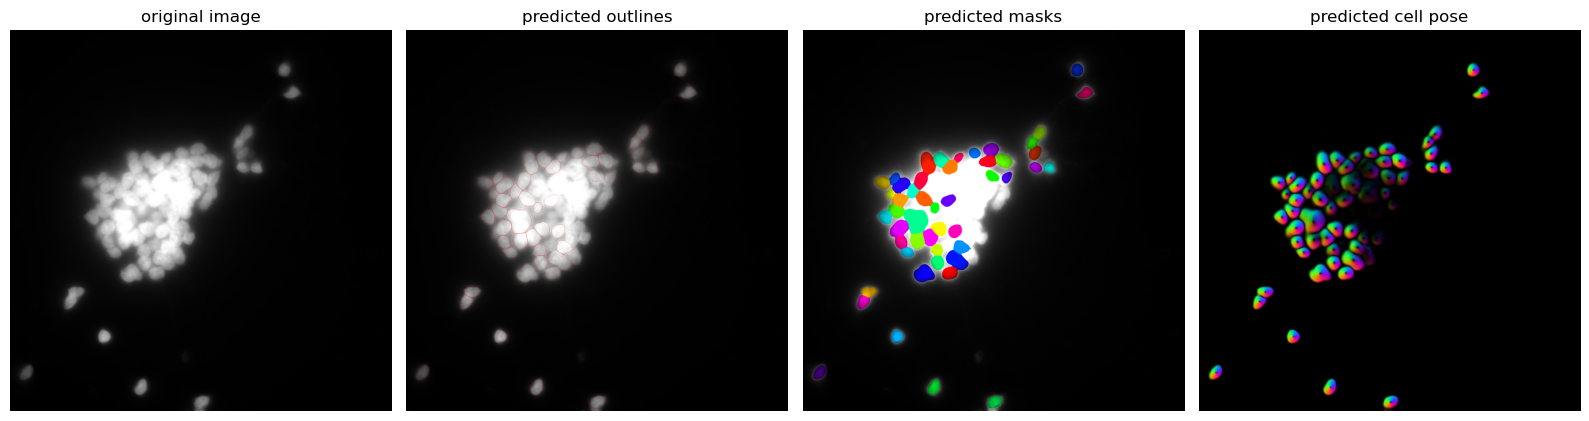

In [54]:
from cellpose import plot
import matplotlib.pyplot as plt

img1 = np.asarray(imgs[64], dtype=np.uint16) # convert image from dask array to numpy array

maski = masks
flowi = flows[0]

fig = plt.figure(figsize=(16,7))
plot.show_segmentation(fig, img1, maski, flowi)
plt.tight_layout()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/ZaneTrit_3_3_2023/figures/cyto2_model_segmentation_plot.png', dpi=300)
plt.show()

## Run cellpose

In [35]:
# RUN CELLPOSE FOR ALL FOVS
from cellpose import models, io
from tqdm import tqdm

# DEFINE CELLPOSE MODEL
# model_type='cyto2' or pretrained_model='<path_to_model>'

# model = models.CellposeModel(gpu=True, pretrained_model=r'C:\Users\zgibbs\cellpose\HCT116_polyA_230320',
#                             device=torch.device(0))

model = models.CellposeModel(gpu=True, pretrained_model=r'C:\Users\zgibbs\cellpose\HCT116_polyA_230320',
                            device=torch.device(0))

# Set the cell diameter manually (will determine automatically if 'None')
# Set the diameter to '0' if using a trained model
# HCT116 diameter = ~245

# masks, flows, styles = model.eval(imgs, channels=[0,0], diameter=0)

masks, flows, styles = [], [], []
for img in tqdm(imgs, desc='Segmented FOVs'):
    mask, flow, style = model.eval(img, channels=[0,0], diameter=0)
    masks.append(mask)
    flows.append(flow)
    styles.append(style)

Segmented FOVs: 100%|████████████████████████████████████████████████████████████████| 184/184 [54:52<00:00, 17.90s/it]


#### Expand mask labels 

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import expand_labels

newmasks = []

for mask in masks:
    newmask = mask.copy()
    for cellid, size in zip(*np.unique(mask, return_counts=True)):
        if size < 2500:
            newmask[newmask==cellid] = 0
    newmask = expand_labels(newmask, 3)
    newmasks.append(newmask)

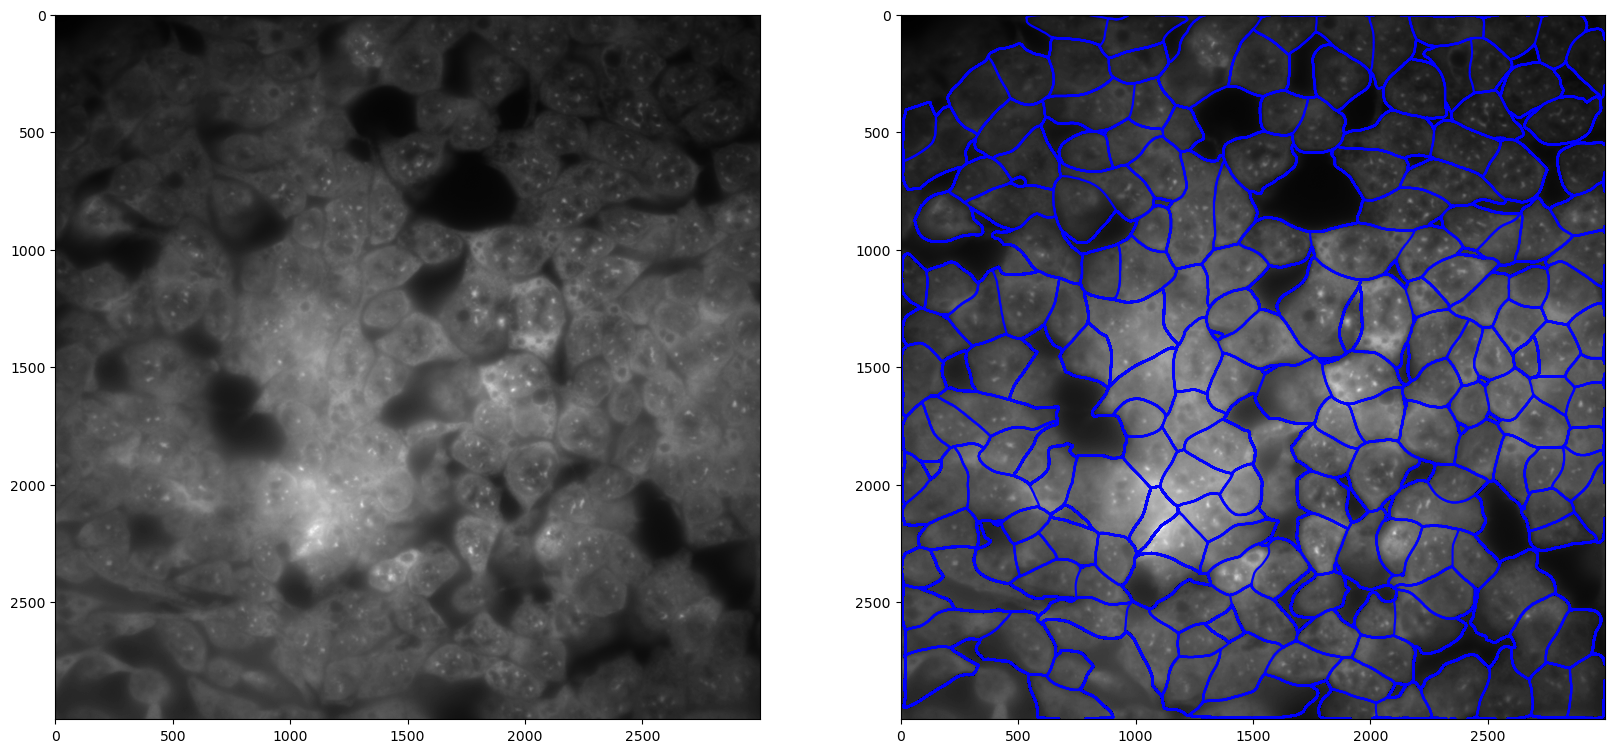

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))

ax[0].imshow(imgs[33], cmap='gray')
ax[1].imshow(imgs[33], cmap='gray')
ax[1].contour(newmasks[33], [0.5+x for x in np.unique(newmasks[33])], colors='b')

In [ ]:
os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

io.masks_flows_to_seg(imgs, newmasks, flows, file_names=savefiles, diams=0) # use 'diams=0' here for pre-trained model
io.save_to_png(imgs, newmasks, flows, file_names=savefiles)

Exception in thread Thread-9:
Traceback (most recent call last):
  File "C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\multiprocessing\pool.py", line 519, in _handle_workers
    cls._wait_for_updates(current_sentinels, change_notifier)
  File "C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\multiprocessing\pool.py", line 499, in _wait_for_updates
    wait(sentinels, timeout=timeout)
  File "C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\multiprocessing\connection.py", line 879, in wait
    ready_handles = _exhaustive_wait(waithandle_to_obj.keys(), timeout)
  File "C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\multiprocessing\connection.py", line 811, in _exhaustive_wait
    res = _winapi.WaitForMultipleObjects(L, False, timeout)
ValueError: need at most

### Save segmentation masks

In [24]:
# os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

In [25]:
savefiles

['/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__000.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__001.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__002.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__003.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__004.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__005.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__006.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__007.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__008.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Con

In [ ]:
os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

io.masks_flows_to_seg(imgs, newmasks, flows, file_names=savefiles, diams=0) # use 'diams=0' here for pre-trained model
io.save_to_png(imgs, newmasks, flows, file_names=savefiles)

### Plot cell centers and/or spots with the segmentation masks